# 2D Poisson Equation — Weak Formulation with `ProblemWeak`

Solve the **Poisson equation** on the unit square using the **Galerkin weak formulation**
with P1 Lagrange test functions and Dunavant cubature:

$$-\nabla^2 u = f \quad \text{in } \Omega = [0,1]^2$$

**Analytical solution (used for validation):**

$$u^*(x,y) = \sin(\pi x)\sin(\pi y), \qquad f(x,y) = 2\pi^2\sin(\pi x)\sin(\pi y)$$

**Boundary conditions:** $u = 0$ on all four sides (Dirichlet).

## Weak form

Multiply by a test function $v \in V_h$ (P1, zero on Dirichlet boundary) and integrate by parts:

$$\int_\Omega \nabla u_\theta \cdot \nabla v \; d\Omega = \int_\Omega f \, v \; d\Omega \qquad \forall v \in V_h$$

The residual for each free node $j$ is:

$$R_j = \int_\Omega \nabla u_\theta \cdot \nabla \varphi_j \; d\Omega - \int_\Omega f \, \varphi_j \; d\Omega$$

and the loss is $\mathcal{L} = \|R\|^2 / n_\text{free}$.

In [1]:
# Must be set before JAX is imported
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_enable_command_buffer="   # disable CUDA command buffers

import pinns
from pinns import DomainMesh, ProblemWeak, create_model, Trainer
import pinns.meshes as meshes

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import jax
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("Available devices:", jax.devices())


JAX backend: gpu
Available devices: [CudaDevice(id=0)]


## 1. Domain

Use the built-in `pinns.meshes.square()` helper — no manual pygmsh setup required.
It returns `(verts, faces)` which `DomainMesh` accepts directly as a tuple.


In [2]:
mesh = meshes.square(x_max=1.0, y_max=1.0, mesh_size=0.05)
print(f"Mesh: {len(mesh[0])} vertices, {len(mesh[1])} triangles")

Mesh: 568 vertices, 1054 triangles


In [3]:
tol = 1e-10

domain = DomainMesh(mesh)

domain.add_boundary(lambda v: v[:, 1] < tol,       name="bottom")   # y = 0
domain.add_boundary(lambda v: v[:, 0] > 1.0 - tol, name="right")    # x = 1
domain.add_boundary(lambda v: v[:, 1] > 1.0 - tol, name="top")      # y = 1
domain.add_boundary(lambda v: v[:, 0] < tol,       name="left")     # x = 0

print(domain)


DomainMesh(2D, n_nodes=568, n_conditions=0, inner_regions=[], boundary_regions=['bottom', 'right', 'top', 'left'])


<Axes: title={'center': 'spatial'}, xlabel='x', ylabel='y'>

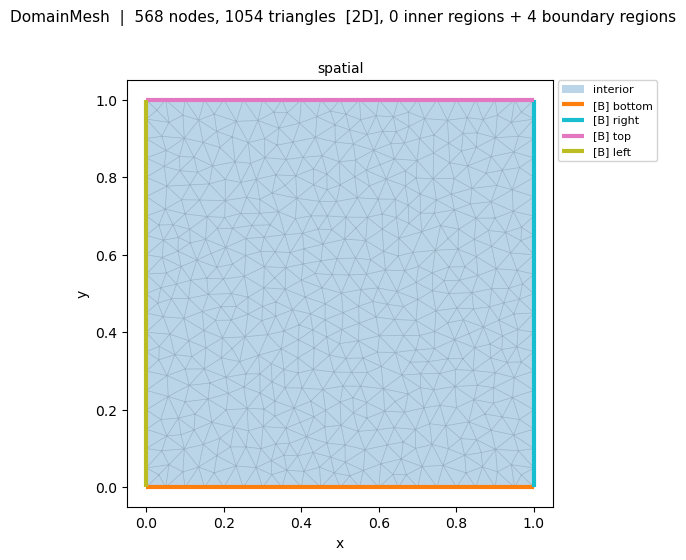

In [4]:
domain.plot(region="all", boundary="custom", backend="matplotlib")

## 2. Define the ProblemWeak

`ProblemWeak` now mirrors `ProblemStrong`'s interface:

```python
problem = ProblemWeak(domain, output_names=[...], cubature_order=3)
problem.add_inner(volume_fn)          # set the bilinear-form integrand
problem.add_dirichlet(0.0, name="bc_bottom", region="bottom")  # Dirichlet BC
problem.add_solution(lambda xy: ...)  # reference solution for validation
```

The `volume_fn` has signature:

```python
volume_fn(x, y, params, phi, derivative) -> (n_qpts,)
```

| arg | shape | meaning |
|-----|-------|---------|
| `x` | `(n, 2)` | quadrature point coordinates |
| `y` | `(n, 1)` | network output at those points |
| `params` | dict | `{"fixed": ..., ...}` |
| `phi` | `(n,)` | test function $\varphi_j$ values |
| `derivative` | callable | `derivative(Y, x, comp, order)`: pass `y` → $\nabla u$, pass `phi` → $\nabla\varphi_j$ |

Dirichlet BCs reference named regions registered on the domain via `domain.add_boundary(select, name=...)`.


In [5]:
def volume_fn(x, y, params, phi, derivative=None):
    """Weak-form integrand: ∇u · ∇φ − f·φ"""
    # ∇u — derivative w.r.t. network output y (2D array)
    du_dx = derivative(y,   x, 0, (0,))    # ∂u/∂x  (n,)
    du_dy = derivative(y,   x, 0, (1,))    # ∂u/∂y  (n,)
    # ∇φ — derivative w.r.t. test function phi (1D array)
    dphi_dx = derivative(phi, x, 0, (0,))  # ∂φ/∂x  (n,)
    dphi_dy = derivative(phi, x, 0, (1,))  # ∂φ/∂y  (n,)

    f = 2.0 * jnp.pi**2 * jnp.sin(jnp.pi * x[:, 0]) * jnp.sin(jnp.pi * x[:, 1])
    return du_dx * dphi_dx + du_dy * dphi_dy - f * phi


problem = ProblemWeak(domain, output_names=["u"], cubature_order=3)

problem.add_inner(volume_fn, name="coco")

# Homogeneous Dirichlet BCs — use region names registered on the domain
problem.add_dirichlet(0.0, name="bottom", region="bottom")
problem.add_dirichlet(0.0, name="right",  region="right")
problem.add_dirichlet(0.0, name="top",    region="top")
problem.add_dirichlet(0.0, name="left",   region="left")

problem.add_solution(lambda xy, params=None: np.sin(np.pi * xy[:, 0]) * np.sin(np.pi * xy[:, 1]))

print(problem)
print(f"\nFree nodes     : {problem.n_free_nodes}")
print(f"Dirichlet nodes: {len(problem.dirichlet_nodes)}")

ProblemWeak(n_verts=568, n_dofs=568, n_faces=1054, n_free=568, n_dirichlet=0, n_neumann_bcs=0, cubature_order=3, lagrange_order=1 (P1, 3 dofs/elem), basis='lagrange')

Free nodes     : 568
Dirichlet nodes: 0


## 3. Build the network and train

`Trainer` detects `ProblemWeak` automatically and replaces the strong-form collocation
residual with the FEM weak-form assembly.


In [6]:
network = create_model(
    domain,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    activation="tanh",
)
print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=2, n_context=0, context_scaled=False)
  [FNN_1] FNN(layer_sizes=[2, 128, 128, 128, 1])


## 4. Training


BC sample counts: {'bottom': 21, 'right': 21, 'top': 21, 'left': 21}
Starting training for 10000 epochs (JIT-compiled)...


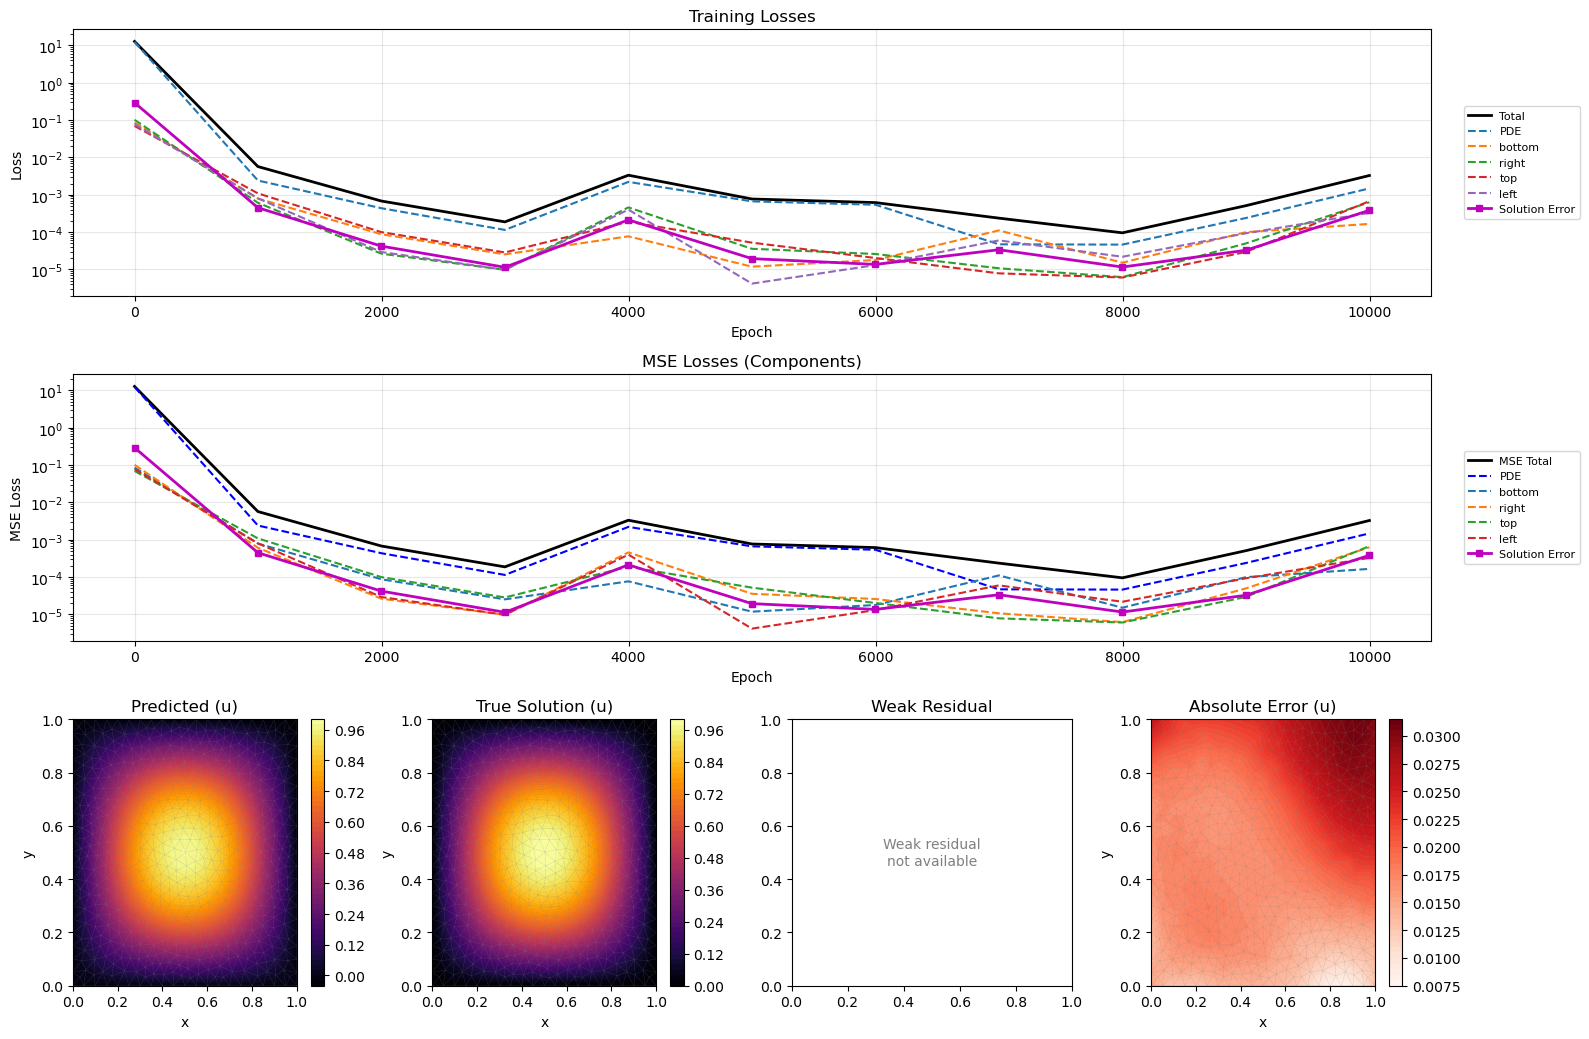

Epoch 0/10000 | Loss: 1.28e+01 | MSE Loss: 1.28e+01 | PDE: 1.24e+01 | BCs: [bottom: 8.54e-02, right: 1.02e-01, top: 6.96e-02, left: 7.79e-02] | Time: 0.0s | Error: 2.93e-01
Epoch 1000/10000 | Loss: 5.70e-03 | MSE Loss: 5.70e-03 | PDE: 2.40e-03 | BCs: [bottom: 7.91e-04, right: 6.10e-04, top: 1.09e-03, left: 8.01e-04] | Time: 5.7s | Error: 4.49e-04
Epoch 2000/10000 | Loss: 6.79e-04 | MSE Loss: 6.79e-04 | PDE: 4.36e-04 | BCs: [bottom: 8.76e-05, right: 2.64e-05, top: 9.99e-05, left: 2.93e-05] | Time: 6.5s | Error: 4.21e-05
Epoch 3000/10000 | Loss: 1.88e-04 | MSE Loss: 1.88e-04 | PDE: 1.14e-04 | BCs: [bottom: 2.53e-05, right: 9.78e-06, top: 2.85e-05, left: 9.79e-06] | Time: 7.3s | Error: 1.14e-05
Epoch 4000/10000 | Loss: 3.34e-03 | MSE Loss: 3.34e-03 | PDE: 2.21e-03 | BCs: [bottom: 7.70e-05, right: 4.59e-04, top: 1.89e-04, left: 4.00e-04] | Time: 8.1s | Error: 2.13e-04
Epoch 5000/10000 | Loss: 7.70e-04 | MSE Loss: 7.70e-04 | PDE: 6.66e-04 | BCs: [bottom: 1.19e-05, right: 3.57e-05, top: 5.22

In [7]:
trainer = Trainer(problem, network)

# Sample each boundary at its full node count
bc_samples = {
    name: len(domain._boundary_regions[name]["node_indices"])
    for name in ("bottom", "right", "top", "left")
}
print("BC sample counts:", bc_samples)

trainer.compile(
    train_samples=bc_samples,
    weights={"coco": 1.0, "bottom": 1.0, "right": 1.0, "top": 1.0, "left": 1.0},
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=1000,
    show_plots=True,
)

trainer.train()
